(stability-chapter)=

# Stability

The stability of a numerical solver for ordinary differential equations refers to its ability to produce accurate and reliable solutions over a long interval, without the computed values of the solution becoming unbounded or oscillatory. In other words, a stable numerical solver for ODEs is one that does not produce solutions that blow up or oscillate wildly as time goes on.

For example, consider the Euler method solution to the following initial value problem using step lengths of $h = 0.25$ and $h = 0.125$

$$ y' = -15y, \qquad t \in [0, 1], \qquad y(0) = 1. $$

The exact solution for this initial value problem is $y = e^{-15t}$ and the numerical solutions are plotted against the exact solution in {numref}`stability-plot-1-figure`. Here we can see that the solution using $h = 0.125$ remains bounded whereas the solution using $h = 0.25$ diverges.

```{glue:figure} stability-plot-1
:name: stability-plot-1-figure
:figwidth: 600

Solutions to the initial value problem $y' = -15y$, $t\in [0, 1]$ and $y(0) = 1$ using the Euler method with $h=0.25$ and $h=0.125$.
```

The solution using $h = 0.125$ is an example of a **stable** solution where the numerical solution remains bounded whereas the solution using $h = 0.25$ is an example of an **unstable** solution which is unbounded. The reason for the instability is due to the truncation of the Taylor series. We saw in the section on [error analysis](error-analysis-section) that the higher order terms that are omitted due to truncation causes a [local truncation error](local-truncation-error-section), and the accumulation of these local truncation errors creates the [global truncation error](global-truncation-error-section). If the local truncation error is too large then the global truncation error will eventually diverge as seen in {numref}`stability-plot-1-figure` causing the solution to be unusable. This provides us with the definition of stability. 

````{prf:definition} Stability
:label: stability-definition

If $e_n$ is the local truncation error of a numerical method defined by

\begin{align*}
    e_n = |y(t_{n}) - y_{n}|,
\end{align*}
   
where $y(t_n)$ is the exact solution and $y_n$ the numerical approximation assuming that the solution at the previous step was exact. The method is considered **stable** if

$$ |e_{n+1} - e_n | \leq 1, $$(stability-equation)

for all steps of the method. If a method is not stable then it is **unstable**.
````

---

## Stiffness

When solving IVPs numerically, some problems behave well and they can be solved accurately using large values of the step length $h$. Other problems force us to use small step lengths use they become unstable. These problems as known as **stiff** problems.

An *informal* definition of stiffness is provided by {cite:t}`lambert:1991`

> "If a numerical method with a finite region of absolute stability, applied to a system with any initial conditions, is forced to use in a certain interval of integration a step length which is excessively small in relation to the smoothness of the exact solution in that interval, then the system is said to be stiff in that interval."

Given a linear system $\mathbf{y}' = A \mathbf{y}$ then the stifness ratio is defined as

$$ S= \frac{\max_i (Re(\lambda_i))}{\min_i (Re(\lambda_i))},$$

where $\lambda_i$ are the eigenvalues of the matrix $A$. If the value of $S$ is *large*, then the system is stiff. For example, consider the system

$$ \begin{align*}
  y_1' &= -1000y_1 + 999y_2, \\
  y_2' &= -y_2.
\end{align*} $$

Here $A = \begin{pmatrix} -1000 & 999 \\ 0 & -1 \end{pmatrix}$, so the eigenvalues satisfy

$$ \begin{align*}
  0 &= | A - \lambda I | \\
  &= \begin{vmatrix}
    -1000 - \lambda & 999 \\
    0 & -1 - \lambda
  \end{vmatrix} \\
  &= (-1000-\lambda) (-1 - \lambda).
\end{align*} $$

So the eigenvalues are $\lambda_1 = -1000$ and $\lambda_2 =-1$ and the stiffness ratio is

$$ S = \frac{\lambda_1}{\lambda_2} = \frac{-1000}{-1} = 1000.$$

Since $S$ is *large* then this is a stiff system. 

A similar analysis can be performed for non-linear systems using the Jacobian matrix to linearalise the system.

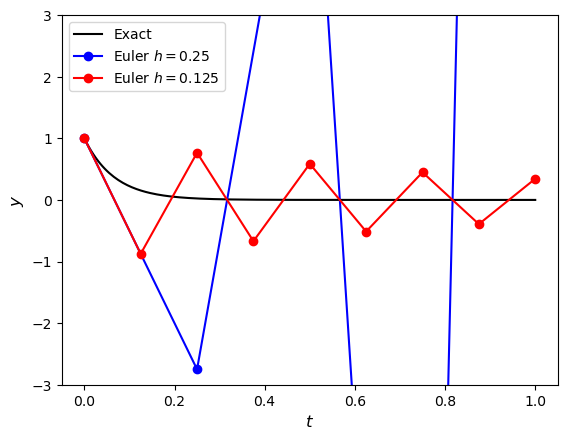

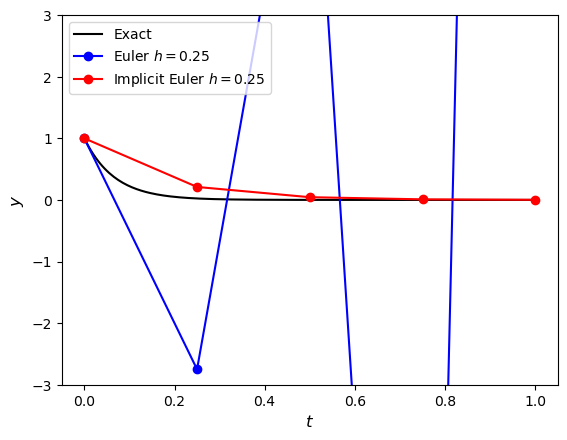

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def euler(f, tspan, y0, h): 

    # Initialise t and y arrays
    t = np.empty(100000)
    y = np.empty((100000,len(y0)))
    t[0] = tspan[0]
    y[0,:] = y0

    # Loop through steps
    n = 0
    while t[n] < tspan[1]:

        # Ensure t does not exceed tspan[1]
        h = min(h, tspan[1] - t[n])
        
        # Calculate Euler method
        y[n+1,:] = y[n,:] + h * f(t[n], y[n,:])
        t[n+1] = t[n] + h
        n += 1
        
    return t[:n+1], y[:n+1,:]


def implicit_euler(f, tspan, y0, h): 

    # Initialise t and y arrays
    t = np.empty(100000)
    y = np.empty((100000,len(y0)))
    t[0] = tspan[0]
    y[0,:] = y0

    # Loop through steps
    n = 0
    while t[n] < tspan[1]:

        # Ensure t does not exceed tspan[1]
        h = min(h, tspan[1] - t[n])
        
        # Calculate Euler method
        y[n+1,:] = y[n,:] / (1 + 15 * h)
        t[n+1] = t[n] + h
        n += 1
        
    return t[:n+1], y[:n+1,:]


# Define ODE function and exact solution
def f(t, y):
    return -15 * y

def exact(t):
    return np.exp(-15 * t)


# Define IVP
tspan = [0, 1]  # boundaries of the t domain
y0 = [1]        # solution at the lower boundary
h1 = 0.25       # step length
h2 = 0.125

# Calculate the solution to the IVP
t1, y1 = euler(f, tspan, y0, h1)
t2, y2 = euler(f, tspan, y0, h2)
t3, y3 = implicit_euler(f, tspan, y0, h1)

# Plot solutions
t_exact = np.linspace(tspan[0], tspan[1], 200)
y_exact = exact(t_exact)
fig, ax = plt.subplots()
plt.plot(t_exact, y_exact, "k", label="Exact")
plt.plot(t1, y1, "bo-", label=f"Euler $h = {h1:0.2f}$")
plt.plot(t2, y2, "ro-", label=f"Euler $h = {h2:0.3f}$")
plt.xlabel("$t$", fontsize=12)
plt.ylabel("$y$", fontsize=12)
plt.ylim([-3,3])
plt.legend()
plt.show()

from myst_nb import glue
glue("stability-plot-1", fig, display=False)

# Plot solutions
t_exact = np.linspace(tspan[0], tspan[1], 200)
y_exact = exact(t_exact)
fig, ax = plt.subplots()
plt.plot(t_exact, y_exact, "k", label="Exact")
plt.plot(t1, y1, "bo-", label=f"Euler $h = {h1:0.2f}$")
plt.plot(t3, y3, "ro-", label=f"Implicit Euler $h = {h1:0.2f}$")
plt.xlabel("$t$", fontsize=12)
plt.ylabel("$y$", fontsize=12)
plt.ylim([-3,3])
plt.legend(loc='upper left')
plt.show()

from myst_nb import glue
glue("stability-plot-2", fig, display=False)